<a href="https://colab.research.google.com/github/Ben-069/DataManPy/blob/main/PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA MANAGEMENT 2026
#URBAN AGRICULTURE AND AND LIFE SATISFACTION IN PARAGUAY
//Author: Benito Ortega Torres
//Affiliation: Departament of Public Policy and Administration - Rutgers University - Camden
//Program: Public Affairs and Community Development PhD.

##URBAN GARDENING IN NJ
incomplete dataset :'(

In [1]:
import requests
import pandas as pd
from getpass import getpass


In [2]:
base_url = "https://services1.arcgis.com/ze0XBzU1FXj94DJq/ArcGIS/rest/services/NJ_Urban_Agriculture_WFL1/FeatureServer/0"

query_url = base_url + "/query"

params = {
    "where": "1=1",          # Todas las observaciones
    "outFields": "*",        # Todas las variables
    "returnGeometry": "false",
    "f": "json"
}
response = requests.get(query_url, params=params)
response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
data = response.json()

In [3]:
# Convertir los atributos a DataFrame
df = pd.DataFrame(
    [feature["attributes"] for feature in data["features"]]
)

df.head()

,OBJECTID,Site_Name,Site_Class,Address,City,Active,Latitude,Longitude,Outdoor_Prod,Indoor_Prod,...,Education,Entrepr_Commercial,Personal_HomeUse,Therapeutic_Spiritual_Meditatio,Ownership,Preserved,Soil_Testing,NOTE,Lat,Long
0,1,Sister Jeans Garden,Community Garden,108 N. Pennsylvania Avenue,Atlantic City,Yes,39.365669771438,-74.42619222149581,,,...,,,,,,,,,39.36567,-74.42619
1,2,ARC Community Garden,Community Garden,1311 N. Main Street,Pleasantville,Yes,39.4118236,-74.50519750000001,,,...,,,,,,,,,39.41182,-74.50520
2,3,Hamilton Memorial Community Garden,Community Garden,605-11 Arctic Avenue,Atlantic City,Yes,39.36781328516018,-74.41932374596328,,,...,,,,,,,,,39.36781,-74.41933
3,4,Mill Creek Urban Farm,Urban Farm,"75 Mill Street, Bridgteon NJ 08302",Bridgeton,Yes,39.4269653521598,-75.22834811576081,Yes,Yes,...,Yes,Yes,,,Public,N,Y,Multiple greenhouses with a focus on hydroponics,39.42696,-75.22835
4,5,Parkside Learning Garden,Community Garden,1221 Hadden Avenue,Camden,Yes,39.9316181,-75.1023684,,,...,,,,,,,,,39.93162,-75.10237


In [4]:
df.shape

(287, 24)

In [5]:
#from google.colab import files

#df.to_csv("NJ_Urban_Agriculture.csv", index=False)
#files.download("NJ_Urban_Agriculture.csv")

##NYC GARDEN DATA
How are land characteristics and physical resources distributed across community gardens in New York City?

Source:https://data.cityofnewyork.us/dataset/GreenThumb-Garden-Info/p78i-pat6/data_preview

In [6]:
import pandas as pd

host = "data.cityofnewyork.us"

garden_url = (
    "https://" + host +
    "/resource/p78i-pat6.csv?$limit=50000"
)

gardens = pd.read_csv(garden_url)

print(gardens.shape)
gardens.head()

(635, 27)


,assemblydist,address,borough,communityboard,congressionaldist,coundist,gardenname,juris,multipolygon,openhrsf,...,policeprecinct,statesenatedist,status,zipcode,bbl,nta,censustract,lat,lon,crossstreets
0,81,435 East 238th Street,X,212,15,11,Growing Good Community Garden,PRI,MULTIPOLYGON (((-73.86374480318754 40.90039177...,11:00 a.m - 6:00 p.m.,...,47,36,Active,10470,2.033920e+09,BX62 /,451.02,40.900243,-73.863808,NaN
1,78,2827 Decatur Ave,X,207,13,15,Oliver's Place,DOT,MULTIPOLYGON (((-73.88595238630586 40.86740172...,NaN,...,52,33,Not GreenThumb,10458,NaN,BX05 /,407.02,40.867004,-73.885891,East 198th and East 199th Streets
2,84,128 Lincoln Avenue,X,201,14,8,Maria Sola Green Space,NYS DOT,MULTIPOLYGON (((-73.92836835468306 40.80842338...,NaN,...,40,29,Not GreenThumb,10454,NaN,BX39 /,19.01,40.808148,-73.929210,NaN
3,79,345 East 153rd Street,X,201,15,17,Melrose Houses Community Garden - Melrose Hous...,NYCHA,MULTIPOLYGON (((-73.91843008455554 40.82142702...,10:00 A.M. - 11:310:00 A.M.- 11:30 A.M & 3:00 ...,...,40,29,Active,10451,2.024130e+09,BX34 /,67.00,40.820762,-73.919546,Morris Ave and courtland ave
4,83,3601 Marolla Place,X,212,16,12,Ujamaa Northeast Community Garden,DOT,MULTIPOLYGON (((-73.83487576713033 40.88368301...,NaN,...,47,36,Active,10466,2.049220e+09,BX03 /,484.01,40.884047,-73.834892,NaN


In [7]:
#from google.colab import files

#gardens.to_csv("NYC_urban_agr.csv", index=False)
#files.download("NYC_urban_agr.csv")

In [8]:
print(gardens.head())

print(gardens.columns)

print(gardens.info())

   assemblydist                address borough  communityboard  \
0            81  435 East 238th Street       X             212   
1            78       2827 Decatur Ave       X             207   
2            84     128 Lincoln Avenue       X             201   
3            79  345 East 153rd Street       X             201   
4            83     3601 Marolla Place       X             212   

   congressionaldist  coundist  \
0                 15        11   
1                 13        15   
2                 14         8   
3                 15        17   
4                 16        12   

                                          gardenname    juris  \
0                      Growing Good Community Garden      PRI   
1                                     Oliver's Place      DOT   
2                             Maria Sola Green Space  NYS DOT   
3  Melrose Houses Community Garden - Melrose Hous...    NYCHA   
4                  Ujamaa Northeast Community Garden      DOT   

       

In [9]:
gardens = gardens[
    [
        "parksid",
        "gardenname",
        "borough",
        "zipcode",
        "status",
        "juris",
        "nta",
        "censustract",
        "lat",
        "lon"
    ]
].copy()

In [10]:
print(gardens.duplicated().sum())

gardens = gardens.drop_duplicates()

print(gardens.shape)

1
(634, 10)


In [11]:
missing = (
    gardens.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing)

lon            56
lat            56
censustract    56
parksid         0
gardenname      0
borough         0
juris           0
status          0
zipcode         0
nta             0
dtype: int64


In [12]:
missing_pct = (
    gardens.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(missing_pct)


lon            8.83
lat            8.83
censustract    8.83
parksid        0.00
gardenname     0.00
borough        0.00
juris          0.00
status         0.00
zipcode        0.00
nta            0.00
dtype: float64


In [13]:
print(gardens["borough"].value_counts())

print(gardens["status"].value_counts())

print(gardens["juris"].value_counts())

print(gardens["zipcode"].nunique())

print(gardens["nta"].nunique())

borough
B    267
M    163
X    134
Q     58
R     12
Name: count, dtype: int64
status
Active                      546
Not GreenThumb               67
Inactive (No Group)           8
Closed (Construction)         6
Active (Unlicensed)           4
Inactive (Group Forming)      3
Name: count, dtype: int64
juris
DPR           395
NYRP           49
NYCHA          36
BQLT           36
PRI            32
BLT            18
MLT            12
DOT            10
DOE             6
DPR/PRI         5
BANG            5
MTA             4
NYS DOT         3
PRI / DOT       2
JOP             2
DEP             2
NYPD (DPR)      2
DEP (DPR)       2
DPR/MLT         2
DOT/MTA         1
DPR/MTA         1
DOE (DPR)       1
DPR/NYRP        1
ACS/PRI         1
NYS PARKS       1
HPD             1
MTA/BQLT        1
DPR/FDNY        1
DCAS (DPR)      1
DCAS            1
Name: count, dtype: int64
104
97


###Descriptive Statistics

In [14]:
# Number of observations and variables
print("Number of observations:", gardens.shape[0])
print("Number of variables:", gardens.shape[1])

Number of observations: 634
Number of variables: 10


In [15]:
borough_counts = gardens["borough"].value_counts()
borough_pct = gardens["borough"].value_counts(normalize=True) * 100

borough_table = pd.DataFrame({
    "Frequency": borough_counts,
    "Percent": borough_pct.round(2)
})

print(borough_table)

         Frequency  Percent
borough                    
B              267    42.11
M              163    25.71
X              134    21.14
Q               58     9.15
R               12     1.89


Interpretation:
-Community gardens are unevenly distributed across New York City.Brooklyn -contains the largest share of gardens, with about 42% of
-all observations, followed by Manhattan and the Bronx.
-Staten Island has substantially fewer gardens than the other boroughs.

In [16]:
#status percentage
status_counts = gardens["status"].value_counts()
status_pct = gardens["status"].value_counts(normalize=True) * 100

status_table = pd.DataFrame({
    "Frequency": status_counts,
    "Percent": status_pct.round(2)
})

print(status_table)

                          Frequency  Percent
status                                      
Active                          546    86.12
Not GreenThumb                   67    10.57
Inactive (No Group)               8     1.26
Closed (Construction)             6     0.95
Active (Unlicensed)               4     0.63
Inactive (Group Forming)          3     0.47


Interpretation
The data shows that 86.12% of the gardens in the dataset are currently active. 10% appears as not part of the greenthumb program. The remaining categories correspond to gardens in the categories of inactive, closed, active but inormal (unlicensed).

In [17]:
#a basic graph

In [18]:
import matplotlib.pyplot as plt

# Convert borough codes to full names
borough_names = {
    "B": "Brooklyn",
    "M": "Manhattan",
    "X": "Bronx",
    "Q": "Queens",
    "R": "Staten Island"
}

gardens["borough_name"] = gardens["borough"].map(borough_names)

# Count gardens by borough
borough_counts = gardens["borough_name"].value_counts()

print(borough_counts)

borough_name
Brooklyn         267
Manhattan        163
Bronx            134
Queens            58
Staten Island     12
Name: count, dtype: int64


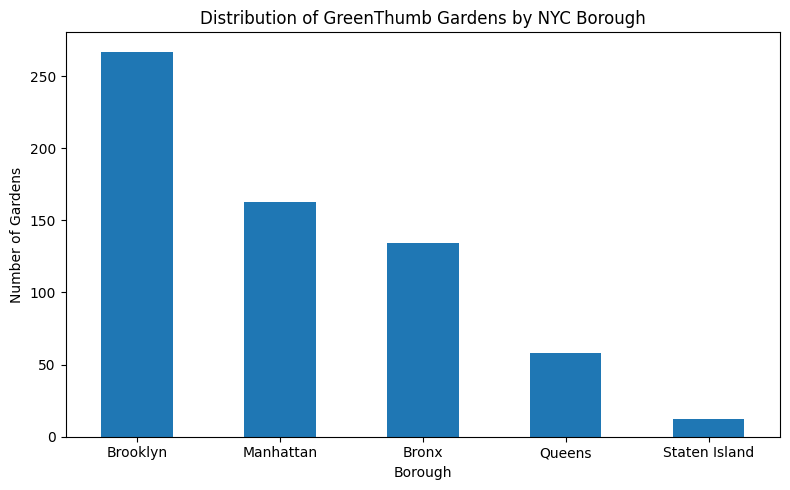

In [19]:
# Community Gardens by Borough
borough_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of GreenThumb Gardens by NYC Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Gardens")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

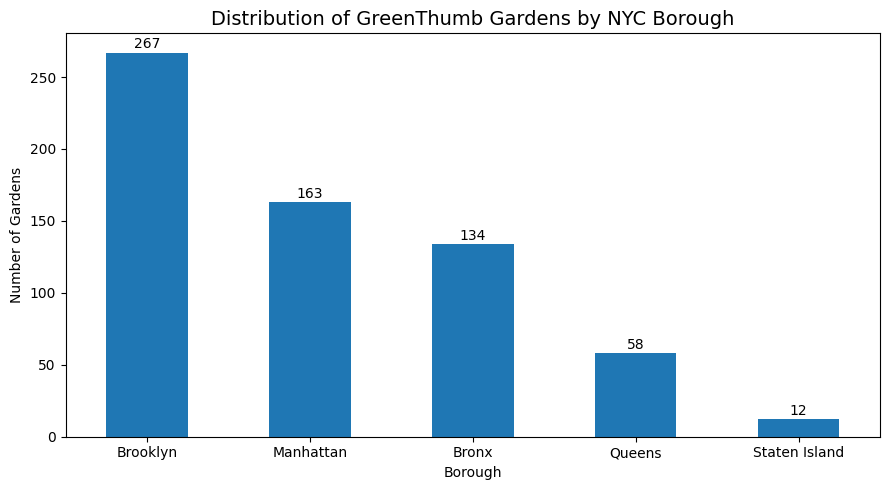

In [20]:
import matplotlib.pyplot as plt

borough_counts = gardens["borough_name"].value_counts()

ax = borough_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Distribution of GreenThumb Gardens by NYC Borough",
    fontsize=14
)

plt.xlabel("Borough")
plt.ylabel("Number of Gardens")
plt.xticks(rotation=0)

# Add numbers above bars
for i, value in enumerate(borough_counts):
    ax.text(
        i,
        value + 3,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

Figure 1.2 shows the the gardes distribution across the 5 boroughs in NYC. We can observe that most of the gardens are located in Brooklyn

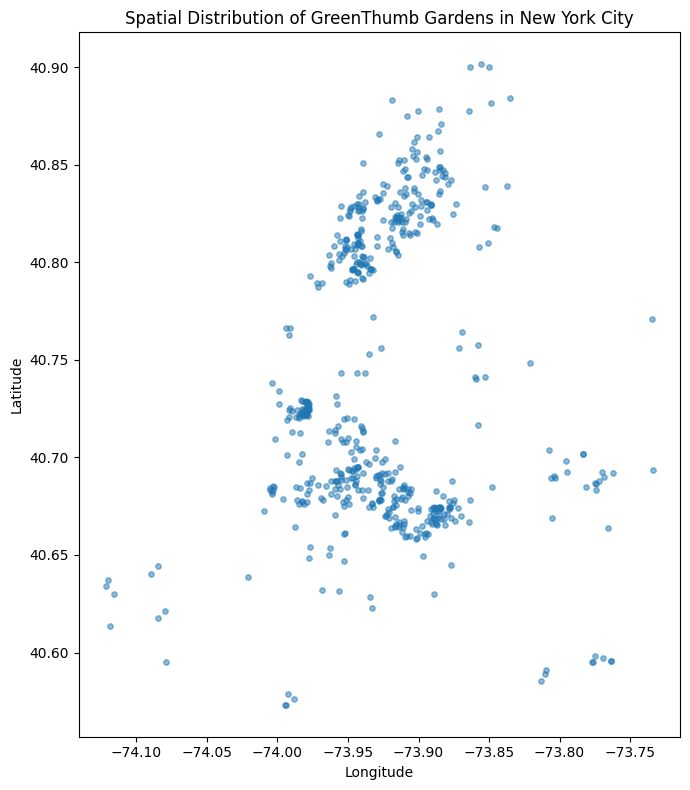

In [21]:
plt.figure(figsize=(7, 8))

plt.scatter(
    gardens["lon"],
    gardens["lat"],
    alpha=0.5,
    s=15
)

plt.title("Spatial Distribution of GreenThumb Gardens in New York City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

#TREES IN PHILADELPHIA AND SOCIOECONOMIC FACTORS

##Getting data

In [22]:
from getpass import getpass
from google.colab import userdata
api_key = userdata.get("api_key")

In [23]:
#official ACS 2024 source
url = ("https://api.census.gov/data/2024/acs/acs5" "?get=NAME,B19013_001E,B17001_001E," "B17001_002E,B25077_001E,B01003_001E" "&for=tract:*" "&in=state:42" "&in=county:101")

In [24]:
#para conseguir mi data del acs
response = requests.get(url, params={"key": api_key},timeout=60)
response.raise_for_status()
print("Status:", response.status_code)

Status: 200


In [25]:
#convert JSON a DataFrame
data = response.json()
acs = pd.DataFrame(data[1:],columns=data[0])
print("Dataset dimensions:", acs.shape)
acs.head()

Dataset dimensions: (408, 9)


,NAME,B19013_001E,B17001_001E,B17001_002E,B25077_001E,B01003_001E,state,county,tract
0,Census Tract 1.01; Philadelphia County; Pennsy...,111148,1963,96,399000,1963,42,101,000101
1,Census Tract 1.02; Philadelphia County; Pennsy...,101033,3156,128,523400,3172,42,101,000102
2,Census Tract 2; Philadelphia County; Pennsylvania,102670,3006,714,-666666666,3103,42,101,000200
3,Census Tract 3; Philadelphia County; Pennsylvania,102104,4446,199,727400,4727,42,101,000300
4,Census Tract 4.01; Philadelphia County; Pennsy...,92182,2919,481,532600,2919,42,101,000401


B19013_001E = Median household income
B17001_001E = Population for whom poverty status is determined
B17001_002E = Population below poverty level
B25077_001E = Median value of owner-occupied housing
B01003_001E = Total population

In [26]:
#renaming weird var names
acs = acs.rename(columns={"B19013_001E": "median_income","B17001_001E": "poverty_universe","B17001_002E": "below_poverty","B25077_001E": "median_home_value","B01003_001E": "population"})

In [27]:
#create a var poverty_rate
acs["poverty_rate"] = (acs["below_poverty"].astype(float) / acs["poverty_universe"].astype(float)) * 100
acs.head(10)

,NAME,median_income,poverty_universe,below_poverty,median_home_value,population,state,county,tract,poverty_rate
0,Census Tract 1.01; Philadelphia County; Pennsy...,111148,1963,96,399000,1963,42,101,000101,4.890474
1,Census Tract 1.02; Philadelphia County; Pennsy...,101033,3156,128,523400,3172,42,101,000102,4.055767
2,Census Tract 2; Philadelphia County; Pennsylvania,102670,3006,714,-666666666,3103,42,101,000200,23.752495
3,Census Tract 3; Philadelphia County; Pennsylvania,102104,4446,199,727400,4727,42,101,000300,4.475933
4,Census Tract 4.01; Philadelphia County; Pennsy...,92182,2919,481,532600,2919,42,101,000401,16.478246
5,Census Tract 4.03; Philadelphia County; Pennsy...,167188,1010,104,915800,1010,42,101,000403,10.297030
6,Census Tract 4.04; Philadelphia County; Pennsy...,96024,2578,136,321800,2588,42,101,000404,5.275407
7,Census Tract 5; Philadelphia County; Pennsylvania,69677,2324,361,435000,3395,42,101,000500,15.533563
8,Census Tract 6; Philadelphia County; Pennsylvania,126033,1846,173,-666666666,1923,42,101,000600,9.371614
9,Census Tract 7.01; Philadelphia County; Pennsy...,85550,2223,221,803900,2229,42,101,000701,9.941520


##Cleaning the Data

In [36]:
import numpy as np

In [37]:
#convert variables from text to numeric
numeric_vars = ["median_income","poverty_universe","below_poverty","median_home_value","population"]
for var in numeric_vars: acs[var] = pd.to_numeric(acs[var], errors="coerce")

In [38]:
#reeplace negative census special values with missing values
acs.loc[acs["median_income"] < 0, "median_income"] = np.nan
acs.loc[acs["median_home_value"] < 0, "median_home_value"] = np.nan

In [39]:
# Recalculate poverty rate
acs["poverty_rate"] = (acs["below_poverty"] / acs["poverty_universe"]) * 100
acs.head(10)

,NAME,median_income,poverty_universe,below_poverty,median_home_value,population,state,county,tract,poverty_rate,GEOID
0,Census Tract 1.01; Philadelphia County; Pennsy...,111148.0,1963,96,399000.0,1963,42,101,000101,4.890474,42101000101
1,Census Tract 1.02; Philadelphia County; Pennsy...,101033.0,3156,128,523400.0,3172,42,101,000102,4.055767,42101000102
2,Census Tract 2; Philadelphia County; Pennsylvania,102670.0,3006,714,NaN,3103,42,101,000200,23.752495,42101000200
3,Census Tract 3; Philadelphia County; Pennsylvania,102104.0,4446,199,727400.0,4727,42,101,000300,4.475933,42101000300
4,Census Tract 4.01; Philadelphia County; Pennsy...,92182.0,2919,481,532600.0,2919,42,101,000401,16.478246,42101000401
5,Census Tract 4.03; Philadelphia County; Pennsy...,167188.0,1010,104,915800.0,1010,42,101,000403,10.297030,42101000403
6,Census Tract 4.04; Philadelphia County; Pennsy...,96024.0,2578,136,321800.0,2588,42,101,000404,5.275407,42101000404
7,Census Tract 5; Philadelphia County; Pennsylvania,69677.0,2324,361,435000.0,3395,42,101,000500,15.533563,42101000500
8,Census Tract 6; Philadelphia County; Pennsylvania,126033.0,1846,173,NaN,1923,42,101,000600,9.371614,42101000600
9,Census Tract 7.01; Philadelphia County; Pennsy...,85550.0,2223,221,803900.0,2229,42,101,000701,9.941520,42101000701


In [41]:
# Create Census GEOID
acs["GEOID"] = (acs["state"].astype(str) + acs["county"].astype(str) + acs["tract"].astype(str))
acs[["NAME", "GEOID"]].head()

,NAME,GEOID
0,Census Tract 1.01; Philadelphia County; Pennsy...,42101000101
1,Census Tract 1.02; Philadelphia County; Pennsy...,42101000102
2,Census Tract 2; Philadelphia County; Pennsylvania,42101000200
3,Census Tract 3; Philadelphia County; Pennsylvania,42101000300
4,Census Tract 4.01; Philadelphia County; Pennsy...,42101000401


##ACS DESCRIPTIVE STATISTICS

In [42]:
acs[["median_income","poverty_rate","median_home_value","population"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
median_income,375.0,68706.97,32657.67,17875.0,43529.00,62083.00,88646.50,227656.00
poverty_rate,390.0,21.21,13.95,0.0,10.23,17.73,29.55,74.09
median_home_value,375.0,295144.80,187048.01,57200.0,163500.00,247800.00,365850.00,1421900.00
population,408.0,3871.83,1815.96,0.0,2664.00,3807.50,4923.25,10596.00


In [43]:
#Iam creating a subset of census tracts where the poverty rate is at least 30 percent
high_poverty = acs[acs["poverty_rate"] >= 30]
print("Number of census tracts with poverty rate >= 30%:",len(high_poverty))
high_poverty[["NAME", "median_income", "poverty_rate", "median_home_value"]].head(10)

Number of census tracts with poverty rate >= 30%: 96


,NAME,median_income,poverty_rate,median_home_value
57,Census Tract 41.03; Philadelphia County; Penns...,55647.0,34.619507,219300.0
63,Census Tract 56; Philadelphia County; Pennsylv...,32411.0,36.633663,116500.0
67,Census Tract 63; Philadelphia County; Pennsylv...,29464.0,48.822800,101700.0
70,Census Tract 66; Philadelphia County; Pennsylv...,25547.0,43.260073,99600.0
77,Census Tract 74; Philadelphia County; Pennsylv...,27902.0,37.003311,156800.0
82,Census Tract 81.01; Philadelphia County; Penns...,37356.0,34.027222,123900.0
84,Census Tract 82; Philadelphia County; Pennsylv...,35741.0,31.199038,199300.0
92,Census Tract 87.02; Philadelphia County; Penns...,51971.0,39.691657,604600.0
93,Census Tract 88.01; Philadelphia County; Penns...,33400.0,47.733333,NaN
94,Census Tract 88.02; Philadelphia County; Penns...,25106.0,55.112219,860800.0


In [44]:
acs.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
median_income,375.0,68706.97,32657.67,17875.0,43529.00,62083.00,88646.50,227656.00
poverty_universe,408.0,3763.90,1816.66,0.0,2581.75,3742.00,4763.75,10418.00
below_poverty,408.0,803.85,658.28,0.0,281.25,649.50,1164.50,3340.00
median_home_value,375.0,295144.80,187048.01,57200.0,163500.00,247800.00,365850.00,1421900.00
population,408.0,3871.83,1815.96,0.0,2664.00,3807.50,4923.25,10596.00
poverty_rate,390.0,21.21,13.95,0.0,10.23,17.73,29.55,74.09


In [46]:
#check invalid poverty denominators
#I subset the data to identify census tracts where the poverty universe equals zero, because a poverty rate cannot be meaningfully calculated when the denominator is zero
zero_poverty_universe = acs[acs["poverty_universe"] == 0]
print("Census tracts with poverty_universe = 0:", len(zero_poverty_universe))
zero_poverty_universe[["NAME", "population", "poverty_universe","below_poverty", "poverty_rate"]]

Census tracts with poverty_universe = 0: 18


,NAME,population,poverty_universe,below_poverty,poverty_rate
387,Census Tract 9800.01; Philadelphia County; Pen...,0,0,0,NaN
388,Census Tract 9800.02; Philadelphia County; Pen...,0,0,0,NaN
389,Census Tract 9800.03; Philadelphia County; Pen...,0,0,0,NaN
392,Census Tract 9803; Philadelphia County; Pennsy...,0,0,0,NaN
393,Census Tract 9804; Philadelphia County; Pennsy...,0,0,0,NaN
394,Census Tract 9805; Philadelphia County; Pennsy...,0,0,0,NaN
395,Census Tract 9806; Philadelphia County; Pennsy...,0,0,0,NaN
396,Census Tract 9807.01; Philadelphia County; Pen...,0,0,0,NaN
397,Census Tract 9807.02; Philadelphia County; Pen...,0,0,0,NaN
398,Census Tract 9808; Philadelphia County; Pennsy...,0,0,0,NaN


In [47]:
#Now I created povery categories
acs["poverty_group"] = pd.cut(acs["poverty_rate"],bins=[0, 10, 20, 30, 100],labels=["Under 10%","10-20%","20-30%","30% or more"],include_lowest=True)
acs[["NAME", "poverty_rate", "poverty_group"]].head(10)

,NAME,poverty_rate,poverty_group
0,Census Tract 1.01; Philadelphia County; Pennsy...,4.890474,Under 10%
1,Census Tract 1.02; Philadelphia County; Pennsy...,4.055767,Under 10%
2,Census Tract 2; Philadelphia County; Pennsylvania,23.752495,20-30%
3,Census Tract 3; Philadelphia County; Pennsylvania,4.475933,Under 10%
4,Census Tract 4.01; Philadelphia County; Pennsy...,16.478246,10-20%
5,Census Tract 4.03; Philadelphia County; Pennsy...,10.297030,10-20%
6,Census Tract 4.04; Philadelphia County; Pennsy...,5.275407,Under 10%
7,Census Tract 5; Philadelphia County; Pennsylvania,15.533563,10-20%
8,Census Tract 6; Philadelphia County; Pennsylvania,9.371614,Under 10%
9,Census Tract 7.01; Philadelphia County; Pennsy...,9.941520,Under 10%


In [48]:
#Mow ready to GROUPBY / AGG yaayyy :)
poverty_summary = (acs.groupby("poverty_group",observed=True).agg(number_of_tracts=("tract", "count"),average_income=("median_income", "mean"),median_income=("median_income", "median"),average_home_value=("median_home_value", "mean"),average_population=("population", "mean")).round(2))
poverty_summary

,number_of_tracts,average_income,median_income,average_home_value,average_population
poverty_group,,,,,
Under 10%,96,103269.27,102104.0,441090.32,3394.39
10-20%,119,73392.82,69298.0,314237.61,4343.75
20-30%,79,54459.87,50950.0,230852.63,4506.25
30% or more,96,36040.20,34632.5,172441.57,3963.46


The descriptive statistics reveal substantial socioeconomic differences across Philadelphia census tracts. Tracts with poverty rates below 10% have an average median household income of approximately $103,269, compared with $36,040 in tracts with poverty rates of 30% or higher. A similar pattern is observed in housing values, with average median home values decreasing from approximately $441,090 to $172,442 across these two groups. obs:These findings provide useful socioeconomic context for examining the spatial distribution of Philadelphia's inventoried urban trees. However, they are descriptive associations and do not establish causal relationships. The estimates are based on census tracts rather than individual households.

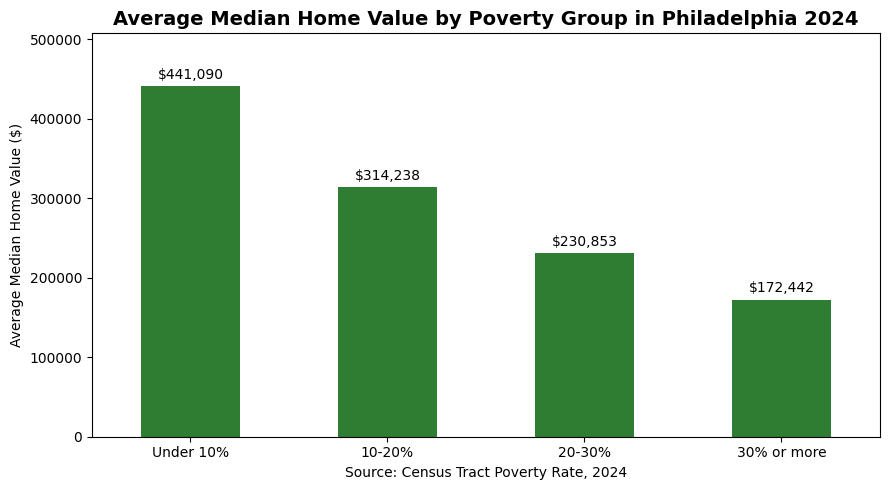

In [51]:
#fancy graph for HOME VALUES BY POVERTY GROUP
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 5))
#a) Create bar chart
poverty_summary["average_home_value"].plot(kind="bar",ax=ax,color="#2E7D32")
#b) Add title and axis labels
ax.set_title("Average Median Home Value by Poverty Group in Philadelphia 2024", fontsize=14,fontweight="bold")
ax.set_xlabel("Source: Census Tract Poverty Rate, 2024")
ax.set_ylabel("Average Median Home Value ($)")
#c) Keep category labels horizontal
plt.xticks(rotation=0)
#d) Add dollar values above the bars
values = poverty_summary["average_home_value"]
ax.bar_label(ax.containers[0],labels=[f"${v:,.0f}" for v in values],padding=3)
#e) Make room for labels
ax.set_ylim(0, values.max() * 1.15)
#f) Improve spacing and save the graph
plt.tight_layout()
plt.savefig("home_values_by_poverty.png",dpi=300,bbox_inches="tight")
plt.show()

##PHILADELPHIA TREE INVENTORY

In [52]:
#Now lets add some trees to the equation B)
tree_url = ("https://hub.arcgis.com/api/v3/datasets/""dc6826e1319c4b35a7b662bc6be68104_0/""downloads/data?format=csv&spatialRefId=3857&where=1%3D1")
trees_raw = pd.read_csv(tree_url)
print("Dataset dimensions:", trees_raw.shape)
display(trees_raw.head())

Dataset dimensions: (151726, 8)


,X,Y,objectid,tree_name,tree_dbh,year,loc_y,loc_x
0,-8.372395e+06,4.863593e+06,1,GINKGO BILOBA - GINKGO,36.0,2025,39.983823,-75.210501
1,-8.372398e+06,4.863580e+06,2,ACER PALMATUM - JAPANESE MAPLE,NaN,2025,39.983734,-75.210532
2,-8.372384e+06,4.863582e+06,3,ACER PALMATUM - JAPANESE MAPLE,8.0,2025,39.983749,-75.210405
3,-8.372406e+06,4.863610e+06,4,ACER PALMATUM - JAPANESE MAPLE,12.0,2025,39.983943,-75.210602
4,-8.372370e+06,4.863583e+06,5,ACER PSEUDOPLATANUS - SYCAMORE MAPLE,17.0,2025,39.983754,-75.210273


##Cleaning
Cleanign messed up stuff like duplicated tree identifiers, convert to numbe, and retain the only the valid coordinates

In [54]:
trees = trees_raw[
    ["objectid", "tree_name", "tree_dbh", "loc_y", "loc_x"]
].copy()

In [55]:
#I Removed duplicate tree identifiers
trees = trees.drop_duplicates(subset="objectid")

In [57]:
# Convert coordinates to numeric
trees["loc_y"] = pd.to_numeric(trees["loc_y"], errors="coerce")
trees["loc_x"] = pd.to_numeric(trees["loc_x"], errors="coerce")

In [59]:
# Retain trees with valid coordinates
trees = trees.dropna(subset=["loc_y", "loc_x"])
print("Trees retained:", len(trees))
display(trees.head())

Trees retained: 151726


,objectid,tree_name,tree_dbh,loc_y,loc_x
0,1,GINKGO BILOBA - GINKGO,36.0,39.983823,-75.210501
1,2,ACER PALMATUM - JAPANESE MAPLE,NaN,39.983734,-75.210532
2,3,ACER PALMATUM - JAPANESE MAPLE,8.0,39.983749,-75.210405
3,4,ACER PALMATUM - JAPANESE MAPLE,12.0,39.983943,-75.210602
4,5,ACER PSEUDOPLATANUS - SYCAMORE MAPLE,17.0,39.983754,-75.210273


##Loading Census track boundaries

In [60]:
import zipfile
import io
import os
import glob

In [61]:
tract_url = ("https://www2.census.gov/geo/tiger/""TIGER2024/TRACT/tl_2024_42_tract.zip")

In [62]:
# Download the shapefile ZIP
response = requests.get(tract_url, timeout=120)
response.raise_for_status()

In [66]:
# Extract files
os.makedirs("/content/tracts", exist_ok=True)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:z.extractall("/content/tracts")


In [69]:
import geopandas as gpd
# Read the shapefile
shp_path = glob.glob("/content/tracts/*.shp")[0]
tracts_pa = gpd.read_file(shp_path)

In [70]:
# Filter Philadelphia County
tracts = tracts_pa[tracts_pa["COUNTYFP"] == "101"][["GEOID", "ALAND", "geometry"]].copy()
print("Philadelphia census tracts:", len(tracts))
print("Coordinate system:", tracts.crs)
display(tracts.head())

Philadelphia census tracts: 408
Coordinate system: EPSG:4269


,GEOID,ALAND,geometry
17,42101036501,1816210,"POLYGON ((-75.02371 40.13005, -75.02301 40.130..."
18,42101000801,99957,"POLYGON ((-75.18329 39.94951, -75.18166 39.951..."
152,42101026301,406340,"POLYGON ((-75.16899 40.07147, -75.16864 40.071..."
153,42101029200,1745920,"POLYGON ((-75.11288 40.02746, -75.1128 40.0274..."
154,42101024400,421189,"POLYGON ((-75.16912 40.02386, -75.16843 40.024..."


### Spatial join of trees and census track


In [72]:
# Convert tree coordinates to geographic points
tree_points = gpd.GeoDataFrame(trees,geometry=gpd.points_from_xy(trees["loc_x"],trees["loc_y"]),crs="EPSG:4326")

In [73]:
# Match coordinate reference systems
tracts = tracts.to_crs(tree_points.crs)

In [74]:
# Assign each tree to a census tract
trees_with_tract = gpd.sjoin(tree_points,tracts[["GEOID", "geometry"]],how="left",predicate="within")


In [76]:
# Check this out B) (so fancy)
print("Trees with a census tract:",trees_with_tract["GEOID"].notna().sum())
print("Trees without a census tract:",trees_with_tract["GEOID"].isna().sum())
display(trees_with_tract[["objectid", "tree_name", "GEOID"]].head(10))

Trees with a census tract: 151368
Trees without a census tract: 358


,objectid,tree_name,GEOID
0,1,GINKGO BILOBA - GINKGO,42101980002
1,2,ACER PALMATUM - JAPANESE MAPLE,42101980002
2,3,ACER PALMATUM - JAPANESE MAPLE,42101980002
3,4,ACER PALMATUM - JAPANESE MAPLE,42101980002
4,5,ACER PSEUDOPLATANUS - SYCAMORE MAPLE,42101980002
5,6,ILEX OPACA - AMERICAN HOLLY,42101980002
6,7,UNKNOWN UNKNOWN - UNKNOWN,42101980002
7,8,KOELREUTERIA PANICULATA - GOLDENRAIN TREE,42101980002
8,9,CORNUS KOUSA - KOUSA DOGWOOD,42101980002
9,10,AMELANCHIER SPECIES - OTHER SERVICEBERRY,42101980002


###Counting invetored trees by census track

In [79]:
tree_counts = (trees_with_tract.dropna(subset=["GEOID"]).groupby("GEOID").agg(tree_count=("objectid", "count")).reset_index())
display(tree_counts.sort_values("tree_count",ascending=False).head(10))
#look at this :)

,GEOID,tree_count
388,42101980002,4902
387,42101980001,3709
397,42101980800,2196
368,42101037300,1770
129,42101012502,1360
363,42101036600,1165
21,42101001201,1162
389,42101980100,1101
3,42101000300,1097
147,42101014400,1060


####Lets merge tress with the ACS data

In [80]:
import numpy as np
#obs: I need to make sure GEOID is stored as text
tracts["GEOID"] = tracts["GEOID"].astype(str)
tree_counts["GEOID"] = tree_counts["GEOID"].astype(str)
acs["GEOID"] = acs["GEOID"].astype(str).str.zfill(11)

In [81]:
#1st: letsstart with every Philly census tract
philly = tracts[["GEOID", "ALAND"]].copy()

In [94]:
#2nd:Add inventoried tree counts
# Drop any existing tree_count related columns to prevent MergeError on re-execution
columns_to_drop = [col for col in ["tree_count", "tree_count_x", "tree_count_y"] if col in philly.columns]
if columns_to_drop:
    philly = philly.drop(columns=columns_to_drop)
philly = philly.merge(tree_counts,on="GEOID",how="left",validate="one_to_one")
# Zero means no trees recorded in this inventory
philly["tree_count"] = (philly["tree_count"].fillna(0).astype(int))

In [95]:
#third: add socioeconomic characteristics vars
philly = philly.merge(acs[["GEOID","NAME","median_income","poverty_rate","median_home_value","population"]],
    on="GEOID",how="left", validate="one_to_one",indicator=True)
print("Merge results:")
print(philly["_merge"].value_counts())
print("\nDataset dimensions:", philly.shape)
display(philly.head())

Merge results:
_merge
both          408
left_only       0
right_only      0
Name: count, dtype: int64

Dataset dimensions: (408, 9)


,GEOID,ALAND,tree_count,NAME,median_income,poverty_rate,median_home_value,population,_merge
0,42101036501,1816210,228,Census Tract 365.01; Philadelphia County; Penn...,60764.0,18.863262,350500.0,5046,both
1,42101000801,99957,296,Census Tract 8.01; Philadelphia County; Pennsy...,116250.0,5.985037,989600.0,1604,both
2,42101026301,406340,171,Census Tract 263.01; Philadelphia County; Penn...,75490.0,5.116796,218900.0,4495,both
3,42101029200,1745920,497,Census Tract 292; Philadelphia County; Pennsyl...,77188.0,10.626487,180200.0,3783,both
4,42101024400,421189,348,Census Tract 244; Philadelphia County; Pennsyl...,63125.0,16.688874,196100.0,3007,both


####Creating a tree density variables

In [96]:
#1st: Convert land area from square meters to km2
philly["area_km2"] = philly["ALAND"] / 1_000_000

In [97]:
#2nd: Number of inventoried trees per km²
philly["trees_per_km2"] = np.where(philly["area_km2"] > 0,philly["tree_count"] / philly["area_km2"],np.nan)

In [98]:
#third Number of inventoried trees per 1,000 residents
philly["trees_per_1000"] = np.where(philly["population"] > 0,philly["tree_count"] / philly["population"] * 1000,np.nan)

In [99]:
# Identify special-use tracts (98xx)
philly["special_tract"] = (philly["GEOID"].str[5:7] == "98")


In [100]:
# Inspect the special-use tracts
display(philly.loc[philly["special_tract"],["GEOID","tree_count","population","area_km2","trees_per_km2"]].sort_values("tree_count", ascending=False))

,GEOID,tree_count,population,area_km2,trees_per_km2
90,42101980002,4902,0,5.921043,827.894680
80,42101980001,3709,0,2.526129,1468.254392
268,42101980800,2196,0,2.103934,1043.758977
162,42101980100,1101,292,5.340607,206.156341
36,42101980500,919,0,0.416088,2208.667397
217,42101989100,856,1190,2.785522,307.303263
6,42101980200,817,68,4.916641,166.170359
313,42101980600,399,0,1.286762,310.080652
91,42101980901,217,0,11.195484,19.382815
320,42101980300,216,0,7.596033,28.435895


Lets move to residential census track

In [101]:
residential = philly[(~philly["special_tract"]) &(philly["population"] > 0)].copy()
print("All Philadelphia tracts:", len(philly))
print("Residential tracts retained:", len(residential))
print("\nTotal trees in spatial join:",tree_counts["tree_count"].sum())
print("Trees assigned in merged dataset:",philly["tree_count"].sum())

All Philadelphia tracts: 408
Residential tracts retained: 387

Total trees in spatial join: 151368
Trees assigned in merged dataset: 151368


In [104]:
#then some summary statistics
display(residential[["tree_count","trees_per_km2","trees_per_1000","median_income","poverty_rate","median_home_value"]].describe().round(2).T)

,count,mean,std,min,25%,50%,75%,max
tree_count,387.0,350.58,234.23,5.00,186.50,287.00,449.50,1770.00
trees_per_km2,387.0,704.11,631.05,21.55,279.04,512.78,853.45,3547.50
trees_per_1000,387.0,102.55,103.02,5.16,45.24,75.09,130.82,1387.10
median_income,374.0,68593.10,32626.78,17875.00,43529.00,62049.00,88475.00,227656.00
poverty_rate,387.0,21.08,13.69,0.00,10.24,17.51,29.47,74.09
median_home_value,375.0,295144.80,187048.01,57200.00,163500.00,247800.00,365850.00,1421900.00


The final residential sample contains 387 census tracts in Philadelphia. The average number of inventoried trees per tract is approximately 351, while the median is 287. Average tree density is approximately 704 trees per square kilometer, compared with a median of 513, suggesting a positively skewed distribution with some tracts containing substantially higher tree densities. The average of tract-level median household incomes is approximately $68,593, and the average tract poverty rate is 21.08%. These findings indicate substantial variation in both environmental and socioeconomic characteristics across Philadelphia.

*for more happiness and fanciness our next step is to examine whether inventoried tree density is associated with neighborhood poverty, median household income, and median home values. These comparisons will be exploratory and will not establish causal relationships.*

###Graph2: Tress and poverty

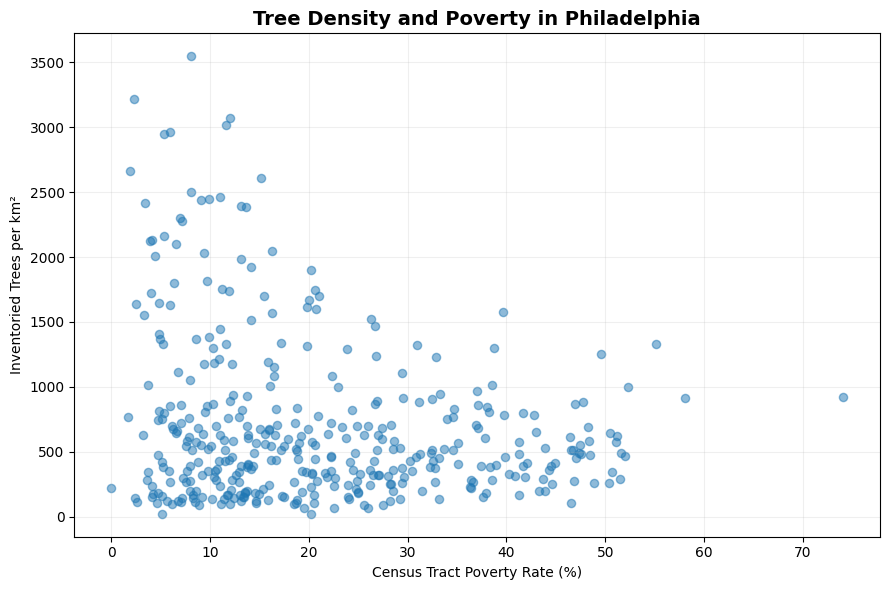

In [105]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

#1stSelect variables and remove missing observations
plot_data = residential[["poverty_rate", "trees_per_km2"]].dropna()
#2nd Create the figure
fig, ax = plt.subplots(figsize=(9, 6))
#3rd Create scatter plot
ax.scatter(plot_data["poverty_rate"],plot_data["trees_per_km2"],alpha=0.5,s=35)
#4th Add title and labels
ax.set_title("Tree Density and Poverty in Philadelphia",fontsize=14,fontweight="bold")
ax.set_xlabel("Census Tract Poverty Rate (%)")
ax.set_ylabel("Inventoried Trees per km²")
# Add some make up (light grid)
ax.grid(alpha=0.2)
# Improve spacing
plt.tight_layout()
# Save and enjoy the view
#plt.savefig("tree_density_poverty.png",dpi=300,bbox_inches="tight")
plt.show()

####Now, is there any correlation?

In [106]:
correlation = plot_data[["poverty_rate", "trees_per_km2"]].corr(method="pearson")
print(correlation.round(3))

               poverty_rate  trees_per_km2
poverty_rate          1.000         -0.214
trees_per_km2        -0.214          1.000


The Pearson correlation between poverty rate and inventoried tree density is -0.214, indicating a weak negative relationship across residential census tracts in Philadelphia. This suggests that census tracts with higher poverty rates tend to have lower densities of inventoried trees per square kilometer. However, the relatively small correlation coefficient indicates substantial variation across neighborhoods.

####What about the rest of the socioeconmic conditions?

In [107]:
variables = ["trees_per_km2","poverty_rate","median_income","median_home_value"]
#Pearson correlation matrix
correlation_matrix = residential[variables].corr(method="pearson")
# lets see what happens :O
print(correlation_matrix.round(3))

                   trees_per_km2  poverty_rate  median_income  \
trees_per_km2              1.000        -0.214          0.438   
poverty_rate              -0.214         1.000         -0.728   
median_income              0.438        -0.728          1.000   
median_home_value          0.646        -0.505          0.711   

                   median_home_value  
trees_per_km2                  0.646  
poverty_rate                  -0.505  
median_income                  0.711  
median_home_value              1.000  


In [110]:
#lets check the sample size for each correlation
for variable in ["poverty_rate","median_income","median_home_value"]:
    complete = residential[["trees_per_km2", variable]].dropna()
    r = complete["trees_per_km2"].corr(complete[variable])
    print(variable,"N =", len(complete),"r =", round(r, 3))

poverty_rate N = 387 r = -0.214
median_income N = 374 r = 0.438
median_home_value N = 375 r = 0.646


he correlation analysis reveals notable associations between inventoried tree density and socioeconomic characteristics across residential census tracts in Philadelphia. The strongest observed association is between tree density and median home value (r = 0.646). Census tracts with higher densities of inventoried trees tend to have higher median home values. A moderate positive relationship is also observed between tree density and median household income (r = 0.438). In contrast, the correlation between tree density and poverty rate is weak and negative (r = -0.214), suggesting that census tracts with higher poverty rates tend to have lower densities of inventoried trees, although substantial variation exists.

####Tree density versus income and home values

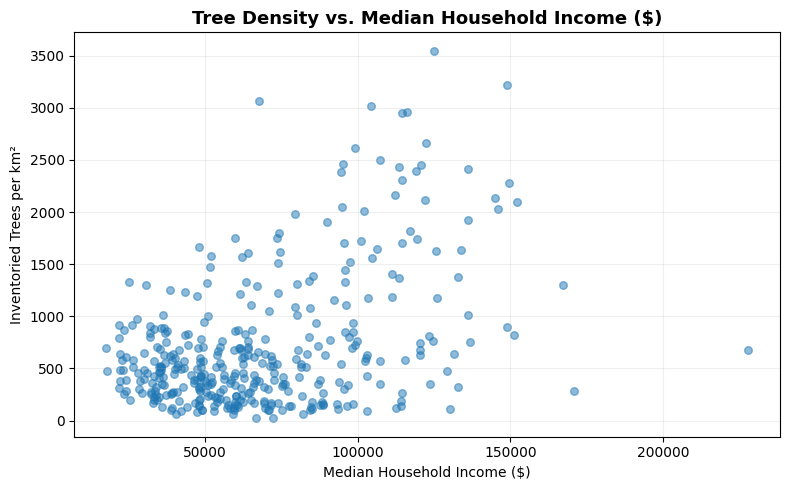

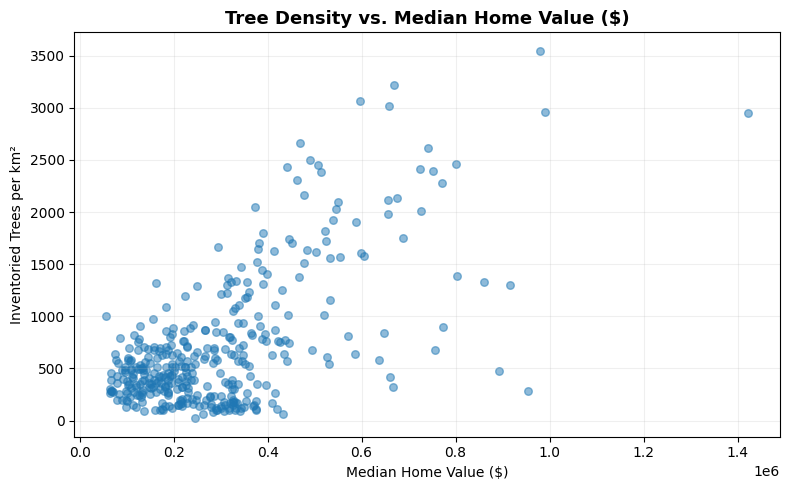

In [112]:
import matplotlib.pyplot as plt

variables = {"median_income": "Median Household Income ($)","median_home_value": "Median Home Value ($)"}
for variable, label in variables.items():
    plot_data = residential[["trees_per_km2", variable]].dropna()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(plot_data[variable],plot_data["trees_per_km2"],alpha=0.5,s=30)
    ax.set_title(f"Tree Density vs. {label}",fontsize=13,fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Inventoried Trees per km²")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [113]:
#ROBUSTNESS CHECK: PEARSON AND SPEARMAN
for variable in ["median_income","median_home_value","poverty_rate"]:subset = residential[["trees_per_km2", variable]].dropna()
pearson = subset["trees_per_km2"].corr(subset[variable],method="pearson")
spearman = subset["trees_per_km2"].corr(subset[variable],method="spearman")
print(variable,"N =", len(subset),"Pearson =", round(pearson, 3),"Spearman =", round(spearman, 3))

poverty_rate N = 387 Pearson = -0.214 Spearman = -0.108


The Pearson correlation between inventoried tree density and poverty rate is -0.214 (N = 387), indicating a weak negative linear association across residential census tracts in Philadelphia.However, the Spearman correlation is considerably weaker (-0.108), suggesting that the monotonic relationship between the two variables is very weak.The difference between these coefficients raises questions about potential outliers and the form of the relationship. Further examination is necessary before drawing conclusions about these factors.
*Overall, the results suggest that neighborhood poverty is weakly associated with inventoried tree density. These findings are descriptive and do not establish causality*

In [116]:
# Compare Pearson and Spearman correlations
for variable in ["median_income", "median_home_value"]: subset = residential[["trees_per_km2", variable]].dropna()
print("\nVariable:",variable)
print("N:", len(subset))
print("Pearson:",round(subset["trees_per_km2"].corr(subset[variable], method="pearson"), 3))
print("Spearman:",round(subset["trees_per_km2"].corr(subset[variable], method="spearman"), 3))


Variable: median_home_value
N: 375
Pearson: 0.646
Spearman: 0.432


In [117]:
# Tree density and median household income
income_data = residential[["trees_per_km2", "median_income"]].dropna()
print("N =", len(income_data))
print("Pearson =",round(income_data["trees_per_km2"].corr(income_data["median_income"],method="pearson"), 3))
print("Spearman =",round(income_data["trees_per_km2"].corr(income_data["median_income"],method="spearman"), 3))

N = 374
Pearson = 0.438
Spearman = 0.278


The correlation analysis examines the relationship between inventoried tree density and three socioeconomic indicators across residential census tracts in Philadelphia: poverty rate, median household income, and median home value.

The results reveal a weak negative Pearson correlation between tree density and poverty rate (r = -0.214, N = 387). However, the Spearman correlation is considerably weaker (ρ = -0.108), indicating a very weak negative rank-based association. Median household income is moderately positively correlated with inventoried tree density (Pearson's r = 0.438, N = 374). The Spearman coefficient is lower (ρ = 0.278), although the positive association persists. The strongest observed linear association is between inventoried tree density and median home value (Pearson's r = 0.646, N = 375). The corresponding Spearman coefficient (ρ = 0.432) is also positive but smaller. Across all three comparisons, the Spearman coefficients are weaker in magnitude than the Pearson coefficients. This difference warrants further investigation of potential outliers, nonlinear relationships, and the distributions of the variables.

In [120]:
common_sample = residential[["trees_per_km2","poverty_rate","median_income","median_home_value"]].dropna()
print("Common sample N:", len(common_sample))
print(common_sample.corr(method="pearson").round(3))

Common sample N: 364
                   trees_per_km2  poverty_rate  median_income  \
trees_per_km2              1.000        -0.223          0.446   
poverty_rate              -0.223         1.000         -0.732   
median_income              0.446        -0.732          1.000   
median_home_value          0.646        -0.496          0.711   

                   median_home_value  
trees_per_km2                  0.646  
poverty_rate                  -0.496  
median_income                  0.711  
median_home_value              1.000  


###Let's see how it looks in a map


In [121]:
#1st: we need a map dataset
# Merge tract geometry with analysis variables
map_data = tracts.merge(philly[["GEOID","tree_count","trees_per_km2","trees_per_1000","median_income","poverty_rate","median_home_value","special_tract"]],on="GEOID",how="left",validate="one_to_one")
print("Map dataset dimensions:", map_data.shape)
display(map_data.head())

Map dataset dimensions: (408, 10)


,GEOID,ALAND,geometry,tree_count,trees_per_km2,trees_per_1000,median_income,poverty_rate,median_home_value,special_tract
0,42101036501,1816210,"POLYGON ((-75.02371 40.13005, -75.02301 40.130...",228,125.536144,45.184304,60764.0,18.863262,350500.0,False
1,42101000801,99957,"POLYGON ((-75.18329 39.94951, -75.18166 39.951...",296,2961.273348,184.538653,116250.0,5.985037,989600.0,False
2,42101026301,406340,"POLYGON ((-75.16899 40.07147, -75.16864 40.071...",171,420.829847,38.042269,75490.0,5.116796,218900.0,False
3,42101029200,1745920,"POLYGON ((-75.11288 40.02746, -75.1128 40.0274...",497,284.663673,131.377214,77188.0,10.626487,180200.0,False
4,42101024400,421189,"POLYGON ((-75.16912 40.02386, -75.16843 40.024...",348,826.232404,115.729963,63125.0,16.688874,196100.0,False


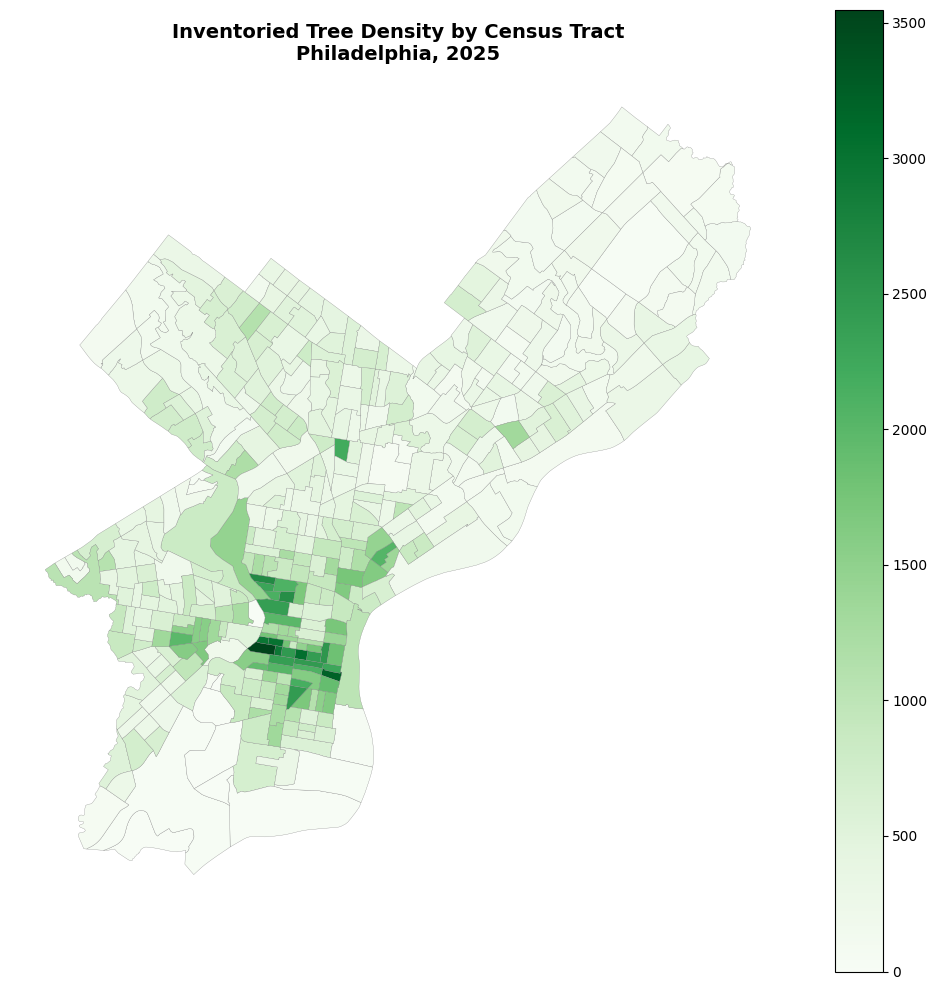

In [122]:
#tree dens by census track
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
map_data.plot(column="trees_per_km2",cmap="Greens",linewidth=0.2,edgecolor="gray",legend=True,ax=ax,missing_kwds={"color": "lightgray","label": "Missing data"})
ax.set_title("Inventoried Tree Density by Census Tract\nPhiladelphia, 2025",fontsize=14,fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig("philly_tree_density_map.png",dpi=300,bbox_inches="tight")
plt.show()

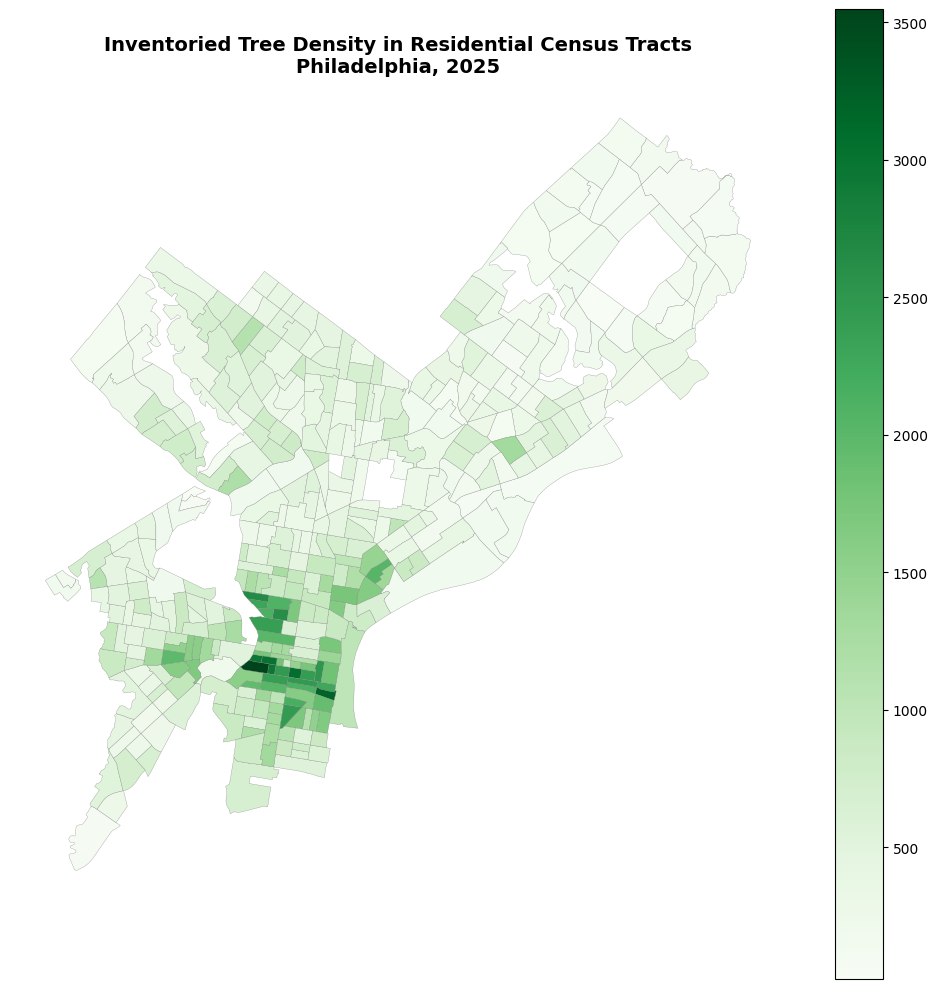

In [123]:
#map of tree density in residential tracks only
fig, ax = plt.subplots(figsize=(10, 10))
map_data[map_data["special_tract"] == False].plot(column="trees_per_km2",cmap="Greens",linewidth=0.2,edgecolor="gray",legend=True,ax=ax,
    missing_kwds={"color": "lightgray","label": "Missing data"})
ax.set_title("Inventoried Tree Density in Residential Census Tracts\nPhiladelphia, 2025",fontsize=14,fontweight="bold")
ax.axis("off")
plt.tight_layout()
#plt.savefig("philly_tree_density_residential_map.png",dpi=300,bbox_inches="tight")

plt.show()

####TREE DENSITY AND HOUSING VALUES

In [126]:
# Philadelphia, 2025 & ACS 2024
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [127]:
#1st: Combine geographic boundaries with our data
map_compare = tracts[["GEOID", "geometry"]].merge(residential[["GEOID", "trees_per_km2", "median_home_value"]],on="GEOID",how="left",validate="one_to_one")

In [128]:
# 2nd:Use the same census tracts in both maps
map_valid = map_compare.dropna(subset=["trees_per_km2", "median_home_value"]).copy()
print("Census tracts mapped:", len(map_valid))

Census tracts mapped: 375


In [130]:
# 3rd:Create four groups (quartiles) for each variable
map_valid["tree_q"], tree_bins = pd.qcut(map_valid["trees_per_km2"],q=4,labels=False,retbins=True)
map_valid["home_q"], home_bins = pd.qcut(map_valid["median_home_value"],q=4,labels=False,retbins=True)


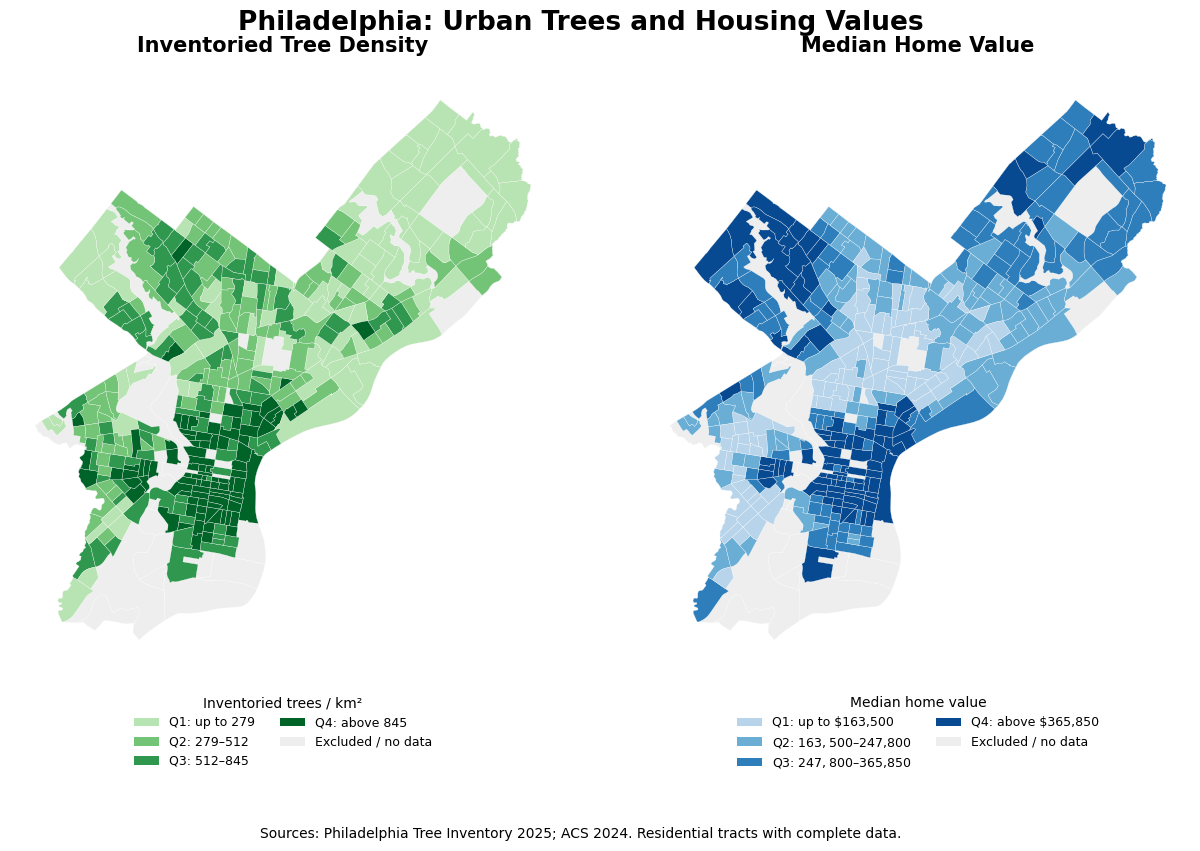

In [135]:
#extrasuperduperfancymap
#4th:Define separate color palettes
greens = plt.cm.Greens(np.linspace(0.3, 0.9, 4))
blues = plt.cm.Blues(np.linspace(0.3, 0.9, 4))
#5th Create two maps side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
# Light background for excluded tracts
for ax in axes:map_compare.plot(ax=ax,color="#eeeeee",edgecolor="white",linewidth=0.2)
# izq: Tree density
map_valid.plot(column="tree_q",ax=axes[0],cmap=ListedColormap(greens),categorical=True,legend=False,edgecolor="white",linewidth=0.2)
axes[0].set_title("Inventoried Tree Density",fontsize=15,fontweight="bold",pad=15)
# der: Median home value
map_valid.plot(column="home_q",ax=axes[1],cmap=ListedColormap(blues),categorical=True,legend=False,edgecolor="white",linewidth=0.2)
axes[1].set_title("Median Home Value",fontsize=15,fontweight="bold",pad=15)

# 6th:create fancy legend labels with actual quartile boundaries
def quartile_labels(bins, money=False):
    def fmt(x):
        return f"${x:,.0f}" if money else f"{x:,.0f}"
    return [f"Q1: up to {fmt(bins[1])}",
            f"Q2: {fmt(bins[1])}–{fmt(bins[2])}",
            f"Q3: {fmt(bins[2])}–{fmt(bins[3])}",
            f"Q4: above {fmt(bins[3])}"]
tree_labels = quartile_labels(tree_bins)
home_labels = quartile_labels(home_bins, money=True)

# 7th: Add compact legends below each map

for ax, colors, labels, legend_title in [(axes[0], greens, tree_labels, "Inventoried trees / km²"),
    (axes[1], blues, home_labels, "Median home value")]:
    handles = [Patch(facecolor=colors[i], label=labels[i])for i in range(4)]
    handles.append(Patch(facecolor="#eeeeee", label="Excluded / no data"))
    ax.legend(handles=handles,title=legend_title,loc="upper center",bbox_to_anchor=(0.5, -0.03),ncol=2,frameon=False,fontsize=9)
    ax.set_axis_off()

# 8th: Final presentation
fig.suptitle("Philadelphia: Urban Trees and Housing Values",fontsize=19,fontweight="bold",y=0.96)
fig.text(0.5, 0.04,"Sources: Philadelphia Tree Inventory 2025; ACS 2024. ""Residential tracts with complete data.",ha="center",fontsize=10)
plt.subplots_adjust(top=0.89,bottom=0.23,wspace=0.05)

# look at this masterpiece
#plt.savefig("philadelphia_trees_housing_maps.png",dpi=300,bbox_inches="tight")
plt.show()

#LIFE SATISFACTION IN PARAGUAY

For this piece of my project I am plannig using data from https://www.latinobarometro.org/, I will use survey data from 2013 to 2024 to see how life satisfaction varies across the years that te survey were conducted in Paraguay. I am aiming to see what is what has more impact on life satisfaction in the country.